In [7]:
from sklearn.datasets import load_iris
import pandas as pd

iris=load_iris()

df=pd.DataFrame(data=iris.data,columns=iris.feature_names)
df['species']=iris.target

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nClass distribution:\n", df['species'].value_counts())
print("\nTarget names:", iris.target_names)
print("\nFeature names:", iris.feature_names)

Dataset shape: (150, 5)

First 5 rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Class distribution:
 species
0    50
1    50
2    50
Name: count, dtype: int64

Target names: ['setosa' 'versicolor' 'virginica']

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nBefore scaling (first row):", X_train[0])
print("After scaling (first row):", X_train_scaled[0])

Training set shape: (120, 4)
Test set shape: (30, 4)

Before scaling (first row): [4.4 2.9 1.4 0.2]
After scaling (first row): [-1.72156775 -0.33210111 -1.34572231 -1.32327558]


In [9]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)

print("Predictions:", y_pred)
print("Actual:     ", y_test)


Predictions: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]
Actual:      [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


Accuracy: 0.9333
F1 Score (macro): 0.9327

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


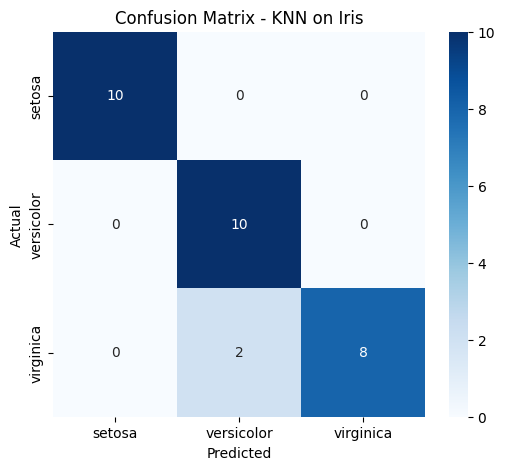


Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [10]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")


f1 = f1_score(y_test, y_pred, average='macro')
print(f"F1 Score (macro): {f1:.4f}")


cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN on Iris')
plt.show()


print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

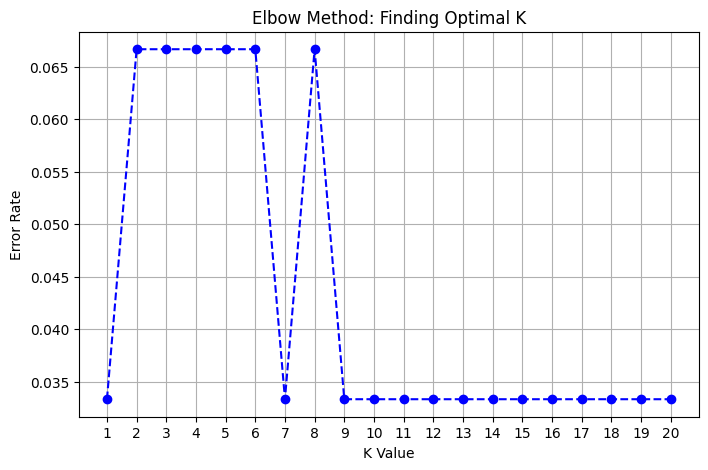

Lowest error rate at K = 1 (error = 0.0333)


In [11]:
import numpy as np

# Try K values from 1 to 20 and record error rate
error_rates = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_k = knn.predict(X_test_scaled)
    error = np.mean(pred_k != y_test)
    error_rates.append(error)

# Plot Error Rate vs K
plt.figure(figsize=(8, 5))
plt.plot(k_range, error_rates, marker='o', linestyle='--', color='blue')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.title('Elbow Method: Finding Optimal K')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Print the best K
best_k = k_range[np.argmin(error_rates)]
print(f"Lowest error rate at K = {best_k} (error = {min(error_rates):.4f})")

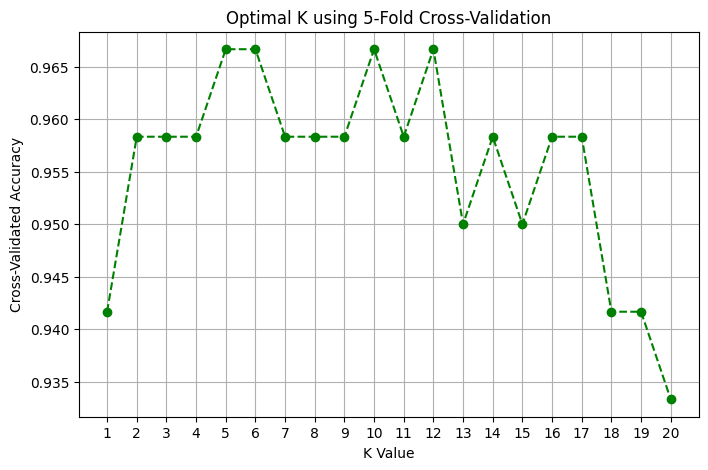

Best K (cross-validation) = 5, accuracy = 0.9667


In [12]:
from sklearn.model_selection import cross_val_score

# Try K values from 1 to 20 using 5-fold cross-validation
cv_scores = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Use the full scaled dataset with 5-fold CV
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores, marker='o', linestyle='--', color='green')
plt.xlabel('K Value')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Optimal K using 5-Fold Cross-Validation')
plt.xticks(k_range)
plt.grid(True)
plt.show()

best_k_cv = k_range[np.argmax(cv_scores)]
print(f"Best K (cross-validation) = {best_k_cv}, accuracy = {max(cv_scores):.4f}")

# Project 2: Data Classification Using AI
### DecodeLabs AI Engineer Industrial Training Kit (Batch 2026)

**Author:** Israt Jahan Mou
**Task:** Build a supervised classification model using a small, well-known dataset.

---

## 1. Overview

This project implements a **K-Nearest Neighbors (KNN)** classifier to predict the species of an iris flower from four physical measurements. It covers the full supervised learning pipeline: data loading, preprocessing, training, and evaluation.

## 2. Dataset

**Iris dataset** (loaded via `sklearn.datasets.load_iris`)

| Property | Value |
|---|---|
| Samples | 150 (balanced) |
| Classes | 3 — *Setosa*, *Versicolor*, *Virginica* (50 each) |
| Features | 4 — Sepal Length, Sepal Width, Petal Length, Petal Width (cm) |

## 3. Methodology

1. **Load & explore** the dataset (shape, class distribution, feature names).
2. **Train-test split** — 80/20, stratified by class, `random_state=42` → 120 training / 30 test samples.
3. **Feature scaling** — `StandardScaler`, fit on the training set only and applied to both sets (prevents data leakage).
4. **Model** — `KNeighborsClassifier` from scikit-learn.
5. **Hyperparameter tuning** — compared K = 1–20 using both a single train/test split and 5-fold cross-validation.
6. **Evaluation** — accuracy, F1-score, confusion matrix, full classification report.

## 4. Results (K = 5)

**Confusion Matrix**

|              | Pred: Setosa | Pred: Versicolor | Pred: Virginica |
|---|---|---|---|
| **Actual: Setosa**     | 10 | 0  | 0 |
| **Actual: Versicolor** | 0  | 10 | 0 |
| **Actual: Virginica**  | 0  | 2  | 8 |

**Classification Report**

| Class | Precision | Recall | F1-score | Support |
|---|---|---|---|---|
| Setosa | 1.00 | 1.00 | 1.00 | 10 |
| Versicolor | 0.83 | 1.00 | 0.91 | 10 |
| Virginica | 1.00 | 0.80 | 0.89 | 10 |
| **Accuracy** | | | **0.93** | 30 |
| Macro avg | 0.94 | 0.93 | 0.93 | 30 |
| Weighted avg | 0.94 | 0.93 | 0.93 | 30 |

**Overall accuracy: 93.3% (28/30 correct)**

## 5. Hyperparameter Tuning

- A single-split elbow method (K = 1–20) produced a noisy, zigzagging error curve — expected given the small (30-sample) test set, where error can only take values like 1/30 or 2/30.
- **5-fold cross-validation** on the training set gave a smoother, more reliable picture. The highest cross-validated accuracy (~96.7%) occurred at K = 5, 6, 10, and 12, with K = 5–6 forming the most stable plateau.
- **K = 5 was retained** as the final choice — it achieved the best cross-validated accuracy, keeps the model simple, and matches the initial configuration.

## 6. Key Observations

- **Setosa** is linearly separable from the other two species and is classified with perfect precision and recall.
- **Versicolor and Virginica** overlap in feature space (their petal/sepal measurements are close), which is the sole source of error: 2 Virginica samples were misclassified as Versicolor. This lowered Versicolor's precision (0.83) and Virginica's recall (0.80).
- No misclassification involved Setosa, consistent with its known botanical distinctness.

## 7. Conclusion

The KNN model, trained on scaled Iris features with K = 5, achieves 93.3% test accuracy and 96.7% cross-validated accuracy. The full pipeline — load, scale, split, train, tune, evaluate — satisfies the Project 2 requirements (data handling, supervised learning basics, model training) from the DecodeLabs Industrial Training Kit.